### <span style="color:#FFA726">Genre-Level Analysis</span>

This notebook has six parts:

1. **Pre-Code Notes** — the plan, caveats, before any code.
2. **Analysis Code** — building genre variety per user, comparing models.
3. **Verifying the genre-data result** — checking why Popularity's genre
   coverage came out so low.
4. **Check if Popularity really lacks usable genre data** — confirming the
   Prime Video / missing-metadata explanation.
5. **Discussion** — interpretation, plus a check for genre clustering across
   all users.
6. **Matching Recommendations to User History** — do recommended genres
   actually match what each user watched.

### <span style="color:#FFA726">1. Pre-Code Notes</span>

**Goal:** check whether MF/ALS's recommendations are more genre-varied per
user than Popularity's, using the metadata we merged earlier (for
interpretation only — genre was never a model input).

**Caveat (from EDA):** `categories` is only usable for ~48% of items, almost
entirely the "Movies & TV" `main_category` — "Prime Video" items are ~89%
missing it. This analysis is therefore limited to that subset, not the full
catalog. `categories` also mixes real genres (e.g. "Comedy", "Drama") with
non-genre labels (studio names, "Movies & TV", "Blu-ray", etc.). We don't
clean this out, it's noted here as a known limitation rather than fixed.

**Steps:**
1. Load the merged dataset (for `parent_asin` → `categories` lookup) and both
   recommendation files.
2. For each user's top-10 list, look up `categories` for items that have it,
   and count distinct labels across those items → "genre variety" for that
   user.
3. Average genre variety per user, separately for Popularity and MF/ALS.
4. Compare.

### <span style="color:#FFA726">2. Analysis Code</span>

In [1]:
import pandas as pd
import numpy as np

merged = pd.read_parquet('datasets/merged_movies_tv.parquet')
popularity_recs = pd.read_parquet('datasets/popularity_recommendations.parquet')
als_recs = pd.read_parquet('datasets/als_recommendations.parquet')

# item -> categories lookup (only items with usable categories)
item_categories = merged.dropna(subset=['categories']).drop_duplicates('parent_asin').set_index('parent_asin')['categories']

print("Items with usable categories:", len(item_categories))
print("Total unique items in merged:", merged['parent_asin'].nunique())

Items with usable categories: 115103
Total unique items in merged: 197943


In [2]:
def genre_variety_per_user(recs_df, item_categories):
    """
    For each user's top10, count distinct genre labels across items that
    have usable categories. Items without categories are skipped.
    Returns: Series indexed by user_id -> genre variety count,
             and the count of users who had zero usable items (fully excluded).
    """
    variety = {}
    zero_coverage_users = 0

    for _, row in recs_df.iterrows():
        user_id = row['user_id']
        top10 = row['top10']

        labels = set()
        for item in top10:
            if item in item_categories.index:
                cats = item_categories.loc[item]
                if cats is not None and len(cats) > 0:
                    labels.update(list(cats))

        if len(labels) == 0:
            zero_coverage_users += 1
        else:
            variety[user_id] = len(labels)

    return pd.Series(variety), zero_coverage_users

In [3]:
pop_variety, pop_zero = genre_variety_per_user(popularity_recs, item_categories)
als_variety, als_zero = genre_variety_per_user(als_recs, item_categories)

print("Popularity — users with usable genre data:", len(pop_variety))
print("Popularity — users with zero usable items (excluded):", pop_zero)
print("Popularity — average genre variety per user:", round(pop_variety.mean(), 2))

print("\nMF/ALS — users with usable genre data:", len(als_variety))
print("MF/ALS — users with zero usable items (excluded):", als_zero)
print("MF/ALS — average genre variety per user:", round(als_variety.mean(), 2))

Popularity — users with usable genre data: 1
Popularity — users with zero usable items (excluded): 657202
Popularity — average genre variety per user: 4.0

MF/ALS — users with usable genre data: 579068
MF/ALS — users with zero usable items (excluded): 78135
MF/ALS — average genre variety per user: 8.58


### <span style="color:#FFA726">3. Verifying the genre-data result </span>

In [4]:
# What are the unique items actually being recommended, and what main_category are they?
pop_unique_items = set(item for top10 in popularity_recs['top10'] for item in top10)
als_unique_items = set(item for top10 in als_recs['top10'] for item in top10)

print("Popularity — unique items ever recommended:", len(pop_unique_items))
print("MF/ALS — unique items ever recommended:", len(als_unique_items))

check = merged[merged['parent_asin'].isin(pop_unique_items.union(als_unique_items))][['parent_asin', 'main_category']].drop_duplicates()
print(check['main_category'].value_counts())

Popularity — unique items ever recommended: 20
MF/ALS — unique items ever recommended: 370
main_category
Prime Video    311
Movies & TV     58
Name: count, dtype: int64


### <span style="color:#FFA726">4. Check if the popularity really lacks usable genre data </span>

In [5]:
pop_only_check = merged[merged['parent_asin'].isin(pop_unique_items)][['parent_asin', 'main_category', 'categories']].drop_duplicates('parent_asin')
print(pop_only_check)
print("\nMain category breakdown for Popularity's 20 items:")
print(pop_only_check['main_category'].value_counts())

     parent_asin main_category                           categories
10    B00PSLQYWE   Prime Video                                 None
46    B00X8UKOUK   Prime Video                                 None
48    B01J4SRJFW   Prime Video                                 None
715   B00TU9UFTS   Prime Video                                 None
918   B005U9RM0W   Prime Video                                 None
1151  B00RSGHX3Q   Prime Video                                 None
1198  B01AB17IGQ   Prime Video                                 None
1238  B007SPQZMC   Prime Video                                 None
1286  B00B8PCLTY   Prime Video                                 None
1409  B009ZQC7MY   Prime Video                                 None
1556  B00RSGIVVO   Prime Video                                 None
1783  B00MR9UY8A   Prime Video                                 None
2382  B01EN8FBG2   Prime Video                                 None
2394  B00I3MQNWG   Prime Video                  

<span style="color:#1A237E">**All 20 of Popularity's unique recommended items are main_category = Prime Video, and 19 of them have categories = None. Exactly one item (B00ZVS46AG) happens to have actual genre labels (['Fantasy', 'Drama', 'Beautiful', 'Gentle']), which is precisely the single user who got "usable genre data" in your earlier result. That one exception matches your earlier EDA finding too — Prime Video isn't 100% missing metadata, just ~89% missing, so a small fraction having it (like this one item) is expected, not an anomaly.

Popularity's recommendation pool is so dominated by Prime Video (which mostly lacks metadata) that genre-level analysis is essentially impossible for it. </span>

### <span style="color:#FFA726">5. Discussion</span>

<span style="color:#1A237E">**Popularity's recommendations are drawn almost entirely from Prime Video items, which lack metadata. Only 1 of 657,203 users had any genre-labeled item in their top-10, making a meaningful average impossible to compute for this model. MF/ALS's recommendations, in contrast, include genre data for 88% of users, averaging 8.58 distinct genres per user's top-10. This reinforces the Coverage finding from the evaluation notebook: MF/ALS's broader catalog reach translates into genre-diverse, more interpretable recommendations, even though this doesn't yet show up as a clear relevance advantage in NDCG@10/Recall@10. </span>

##### <span style="color:#BA68C8">Checking for genre clustering across all users</span>

The average genre variety per user (8.58) only shows diversity *within* each
user's own top-10 — it doesn't tell us whether the *same* genres keep
reappearing across different users. To check that, we count how often each
genre label appears across *all* users' MF/ALS recommendations combined. If a
small handful of genres dominate this count, MF/ALS is effectively recycling
the same popular genres for everyone, even if each individual list looks
varied. If the counts are more evenly spread, that supports genuine diversity
across the recommendation set as a whole.

In [6]:
from collections import Counter

genre_counter = Counter()

for _, row in als_recs.iterrows():
    top10 = row['top10']
    for item in top10:
        if item in item_categories.index:
            cats = item_categories.loc[item]
            if cats is not None and len(cats) > 0:
                genre_counter.update(list(cats))

print("Top 15 most frequently recommended genre labels (MF/ALS):")
for genre, count in genre_counter.most_common(15):
    print(genre, count)

Top 15 most frequently recommended genre labels (MF/ALS):
Movies & TV 1622106
Drama 767048
Blu-ray 663047
Featured Categories 579568
Action & Adventure 511629
Suspense 325958
Science Fiction 268411
Studio Specials 253408
Genre for Featured Categories 227549
Action 213650
Award Winners in Movies & TV 197893
Oscar Central 166641
Past Oscar Winners 166625
Downbeat 157614
Bleak 147507


Plot the results

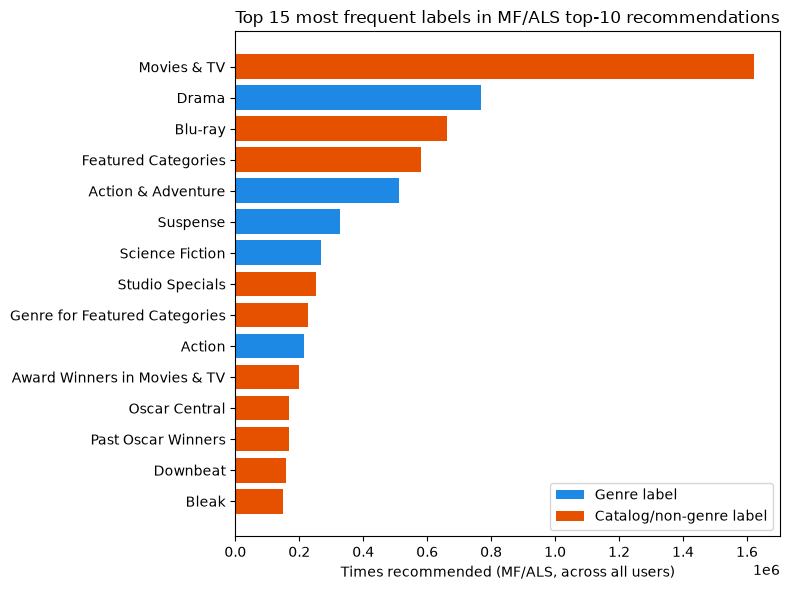

In [7]:
import matplotlib.pyplot as plt

# Manually flagging which of the top 15 are real genre labels vs. catalog/noise
# (per the caveat in Part 1 — categories mixes both)
genre_labels = {
    'Drama', 'Action & Adventure', 'Suspense', 'Science Fiction', 'Action'
}

top15 = genre_counter.most_common(15)
labels = [g for g, _ in top15]
counts = [c for _, c in top15]
colors = ['#1E88E5' if g in genre_labels else '#E65100' for g in labels]

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = range(len(labels))
ax.barh(y_pos, counts, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # highest count on top
ax.set_xlabel('Times recommended (MF/ALS, across all users)')
ax.set_title('Top 15 most frequent labels in MF/ALS top-10 recommendations')

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1E88E5', label='Genre label'),
    Patch(facecolor='#E65100', label='Catalog/non-genre label')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

<span style="color:#1A237E">**Interpretation**: Genre labels and catalog labels are interleaved throughout the top 15, not separated — "Movies & TV" (the single most frequent label) and several catalog/collection tags (Blu-ray, Featured Categories, Studio Specials, Award Winners, Oscar Central) sit alongside real genres (Drama, Action & Adventure, Suspense, Science Fiction, Action). Among the genuine genre labels, Drama and Action & Adventure dominate by a wide margin — so even setting the noise aside, MF/ALS's recommendations do cluster around a small number of genres rather than spreading evenly, which qualifies the earlier "genre variety" finding: individual lists may look varied, but in aggregate the same few genres keep recurring across users. </span>

### <span style="color:#FFA726">6. Matching Recommendations to User History </span>

**Goal:** Part 5 showed which genres MF/ALS leans toward in aggregate, but not
whether an individual user's recommendations reflect what *that user* actually
watched. Here, for each user, we compare the genre labels in their train-history
items against the genre labels in their top-10 recommendations, and compute what
fraction overlaps. We do this once using all `categories` labels (including
catalog/collection noise), then again restricted to a curated list of real genre
labels only, since noise dilutes the raw result.

**Caveat:** `categories` was never a model input for either method — this measures
a correlation with viewing history, not something either model was optimized for.
Same coverage limitation as before applies (only items/users with usable
`categories`).

**Steps:**
1. Build each user's history genre set from `train`.
2. Compute per-user match ratio (all labels) for Popularity and MF/ALS —
   Popularity has too few usable items to compare meaningfully (see Part 3/4).
3. Repeat restricted to a curated genre-only label set, and plot the distribution.
4. Sample individual users to see concrete matched/unmatched genres.

In [8]:
# Genre labels each user was actually exposed to, from their train interactions
# (same category-usability caveat as before: only items with usable `categories`)
train = pd.read_parquet('datasets/train.parquet')
user_history_genres = {}
for user_id, group in train.groupby('user_id')['categories']:
    labels = set()
    for cats in group:
        if cats is not None and len(cats) > 0:
            labels.update(list(cats))
    if labels:
        user_history_genres[user_id] = labels

print("Users with usable history genres:", len(user_history_genres))

Users with usable history genres: 491293


In [9]:
def genre_match_ratio(recs_df, item_categories, user_history_genres):
    """
    For each user: what fraction of the genre labels in their top-10
    recommendations also appear in their own train-history genres?
    Users with no usable history genres, or no usable rec genres, are skipped.
    """
    ratios = {}
    for _, row in recs_df.iterrows():
        user_id = row['user_id']
        history = user_history_genres.get(user_id)
        if not history:
            continue

        top10 = row['top10']
        rec_labels = set()
        for item in top10:
            if item in item_categories.index:
                cats = item_categories.loc[item]
                if cats is not None and len(cats) > 0:
                    rec_labels.update(list(cats))

        if not rec_labels:
            continue

        ratios[user_id] = len(rec_labels & history) / len(rec_labels)

    return pd.Series(ratios)

pop_match = genre_match_ratio(popularity_recs, item_categories, user_history_genres)
als_match = genre_match_ratio(als_recs, item_categories, user_history_genres)

print("Popularity — users compared:", len(pop_match), "| avg match ratio:", round(pop_match.mean(), 3))
print("MF/ALS — users compared:", len(als_match), "| avg match ratio:", round(als_match.mean(), 3))

Popularity — users compared: 1 | avg match ratio: 0.25
MF/ALS — users compared: 443207 | avg match ratio: 0.313


In [10]:
GENRE_LABELS = {
    'Action', 'Adventure', 'Action & Adventure', 'Comedy', 'Drama', 'Horror',
    'Thriller', 'Suspense', 'Science Fiction', 'Fantasy', 'Romance',
    'Documentary', 'Animation', 'Kids', 'Family', 'Musical', 'Mystery',
    'War', 'Western', 'Biography', 'Crime', 'Sports', 'Historical',
    'Military and War'
}

MF/ALS — users compared (genre-only): 384149
MF/ALS — avg genre-only match ratio: 0.403


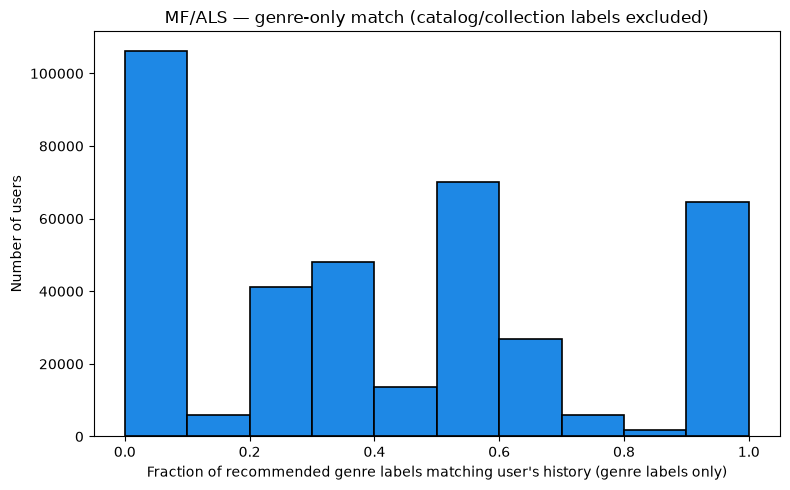

In [11]:
def genre_match_ratio_filtered(recs_df, item_categories, user_history_genres, genre_filter):
    recs_lookup = recs_df.set_index('user_id')['top10']
    ratios = {}
    for user_id, history in user_history_genres.items():
        history_g = history & genre_filter
        if not history_g or user_id not in recs_lookup.index:
            continue
        top10 = recs_lookup.loc[user_id]
        rec_labels = set()
        for item in top10:
            if item in item_categories.index:
                cats = item_categories.loc[item]
                if cats is not None and len(cats) > 0:
                    rec_labels.update(list(cats))
        rec_g = rec_labels & genre_filter
        if not rec_g:
            continue
        ratios[user_id] = len(rec_g & history_g) / len(rec_g)
    return pd.Series(ratios)

als_match_genre_only = genre_match_ratio_filtered(als_recs, item_categories, user_history_genres, GENRE_LABELS)
print("MF/ALS — users compared (genre-only):", len(als_match_genre_only))
print("MF/ALS — avg genre-only match ratio:", round(als_match_genre_only.mean(), 3))

fig, ax = plt.subplots(figsize=(8, 5))
bins = [i / 10 for i in range(11)]
ax.hist(als_match_genre_only, bins=bins, color='#1E88E5', edgecolor='black', linewidth=1.2)
ax.set_xlabel("Fraction of recommended genre labels matching user's history (genre labels only)")
ax.set_ylabel('Number of users')
ax.set_title('MF/ALS — genre-only match (catalog/collection labels excluded)')
plt.tight_layout()
plt.show()

The histogram's uneven bar heights reflect the fact that match_ratio is computed from a small number of distinct genre labels per user, so only a limited set of fraction values is achievable, which is expected.

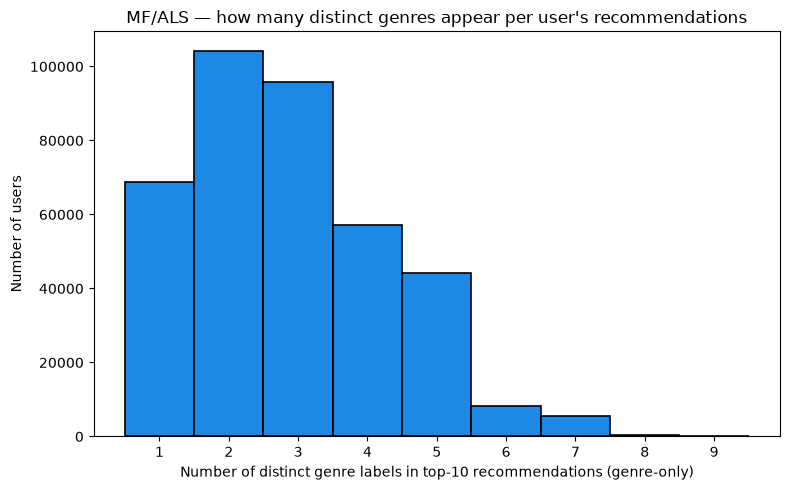

Median distinct genres per user: 3.0
Mean distinct genres per user: 2.87


In [12]:
# Number of distinct genre labels (genre-only) in each user's top-10 recommendations
# — this is the denominator behind match_ratio, and explains why the previous
# histogram's bars were uneven (few possible denominators = few possible ratios)
recs_lookup = als_recs.set_index('user_id')['top10']
rec_genre_counts = {}

for user_id in als_match_genre_only.index:
    top10 = recs_lookup.loc[user_id]
    rec_labels = set()
    for item in top10:
        if item in item_categories.index:
            cats = item_categories.loc[item]
            if cats is not None and len(cats) > 0:
                rec_labels.update(list(cats))
    rec_genre_counts[user_id] = len(rec_labels & GENRE_LABELS)

rec_genre_counts = pd.Series(rec_genre_counts)

fig, ax = plt.subplots(figsize=(8, 5))
max_count = rec_genre_counts.max()
ax.hist(rec_genre_counts, bins=range(1, max_count + 2), color='#1E88E5',
        edgecolor='black', linewidth=1.2, align='left')
ax.set_xlabel('Number of distinct genre labels in top-10 recommendations (genre-only)')
ax.set_ylabel('Number of users')
ax.set_title("MF/ALS — how many distinct genres appear per user's recommendations")
ax.set_xticks(range(1, max_count + 1))
plt.tight_layout()
plt.show()

print("Median distinct genres per user:", rec_genre_counts.median())
print("Mean distinct genres per user:", round(rec_genre_counts.mean(), 2))

Most users' top-10 recommendations span only 1–3 distinct genres (median 3), confirming that MF/ALS's genre clustering (Part 5) holds at the individual level, not just in aggregate, and explains why the match-ratio distribution above is concentrated at a small set of 'round' fraction values rather than spread continuously.

In [13]:
pd.set_option('display.max_colwidth', None)

def genre_match_detail_filtered(user_ids, recs_df, item_categories, user_history_genres, genre_filter):
    recs_lookup = recs_df.set_index('user_id')['top10']
    rows = []
    for user_id in user_ids:
        history = user_history_genres.get(user_id, set()) & genre_filter
        top10 = recs_lookup.loc[user_id]
        rec_labels = set()
        for item in top10:
            if item in item_categories.index:
                cats = item_categories.loc[item]
                if cats is not None and len(cats) > 0:
                    rec_labels.update(list(cats))
        rec_labels = rec_labels & genre_filter
        matched = rec_labels & history
        rows.append({
            'user_id': user_id,
            'history_genres': ', '.join(sorted(history)) if history else '—',
            'recommended_genres': ', '.join(sorted(rec_labels)) if rec_labels else '—',
            'matched_genres': ', '.join(sorted(matched)) if matched else '—',
            'match_ratio': round(len(matched) / len(rec_labels), 2) if rec_labels else None
        })
    return pd.DataFrame(rows)

sample_users = als_match_genre_only.sample(15, random_state=42).index
cross_table_genre = genre_match_detail_filtered(sample_users, als_recs, item_categories, user_history_genres, GENRE_LABELS)

cross_table_genre.style.set_properties(**{'text-align': 'left'}).format({'match_ratio': '{:.2f}'})

,user_id,history_genres,recommended_genres,matched_genres,match_ratio
0,AGTN4DZY5KKT6KJX6CFH23NABN7Q,Action & Adventure,Action & Adventure,Action & Adventure,1.00
1,AHIVSX3WQFVLNZMNCYDCYWOJAW6A,"Comedy, Sports","Drama, Suspense",—,0.00
2,AFMU4B4QB2TIY2NMD3OQYZVMETLA,"Comedy, Drama, Romance, Science Fiction, Suspense","Drama, Science Fiction, Suspense","Drama, Science Fiction, Suspense",1.00
3,AEIMBFM5FVJLSPYHDSXFUXII4TUQ,"Comedy, Science Fiction","Action, Adventure, Drama, Science Fiction, Suspense",Science Fiction,0.20
4,AHDBMW7AGSO7KRPZIC6VQ7PNK63Q,Drama,"Action, Action & Adventure, Adventure, Drama, Suspense",Drama,0.20
5,AEK26324Y2JWZMZRLMAN6ZJZYTLQ,"Action & Adventure, Drama","Action, Comedy, Science Fiction",—,0.00
6,AFDWNYPISURWQGFTDRJNJ5JRC6FQ,Action & Adventure,Action & Adventure,Action & Adventure,1.00
7,AHGELNUX3UTV2C2TI4FQ2NICTVQQ,"Action & Adventure, Drama","Action, Comedy, Science Fiction",—,0.00
8,AFVI3CR47V5IEMIYXU7IVOIJFDRQ,Action & Adventure,Action & Adventure,Action & Adventure,1.00
9,AGSEZBRI3ZLAPZDGIBUSV56OM3JQ,"Action, Action & Adventure, Drama, Science Fiction","Action, Comedy, Drama, Horror, Science Fiction","Action, Drama, Science Fiction",0.60


<span style="color:#1A237E">**Interpretation**: Popularity can't be meaningfully compared here — only 1 of its
20 recommended items has usable genre data (Part 3/4). For MF/ALS, the all-label
match ratio averages 0.313; restricting to real genre labels only raises it to
0.403, confirming that catalog/collection noise (e.g. "Movies & TV", "Blu-ray")
was diluting the genre-only signal.</span>

<span style="color:#1A237E">More notably, the genre-only distribution is bimodal, not centered around its
mean: a large group of users (~106k) has near-zero genre overlap between
recommendations and history, while a comparably large group (~65k) has near-total
overlap. The sample table above shows both cases concretely — e.g. row 6
("Action & Adventure, Drama" → "Action & Adventure", ratio 1.0) vs. row 12
("Science Fiction" → "Action & Adventure", ratio 0.0). This means MF/ALS's genre
consistency isn't uniform across users: for some, collaborative-filtering signal
happens to align with genre preference, while for others it doesn't — likely
reflecting how much of a given user's taste is genre-driven vs. driven by other
factors (actors, franchises) the model can't distinguish. This is a more
informative picture than the single average would suggest.</span>

#### <span style="color:#BA68C8">Saving</span>

In [14]:
genre_summary = pd.DataFrame({
    'Model': ['Popularity', 'MF/ALS'],
    'Users with usable genre data': [len(pop_variety), len(als_variety)],
    'Avg genre variety per user': [pop_variety.mean(), als_variety.mean()],
    'Users compared (match ratio, all labels)': [len(pop_match), len(als_match)],
    'Avg match ratio (all labels)': [pop_match.mean(), als_match.mean()],
})

genre_summary.to_csv('datasets/genre_analysis_summary.csv', index=False)
cross_table_genre.to_csv('datasets/genre_match_sample_users.csv', index=False)

print("Saved genre_analysis_summary.csv and genre_match_sample_users.csv")

Saved genre_analysis_summary.csv and genre_match_sample_users.csv
